# dagsampler — Templates & Feature Spotlight

This notebook demonstrates:

1. **Template DAGs** — `chain_config`, `fork_config`, `collider_config` for common shapes.
2. **Sigmoid / cos / sin** structural forms.
3. **Post-nonlinear transforms** (`tanh`, `sin`, `cos`, …).
4. **Heavy-tailed noise** (`laplace`, `cauchy`).
5. **Mixed-type DAGs** with categorical → continuous via `stratum_means`.

Read [`01_quickstart.ipynb`](./01_quickstart.ipynb) first if you haven't already.

In [1]:
from dagsampler import (
    CausalDataGenerator,
    chain_config,
    fork_config,
    collider_config,
)

## 1. Template DAGs

Templates build a config dict for you. The argument shapes are documented at
[Template Configurations](https://averinpa.github.io/dagsampler/templates.html).

### Chain: X → M → Y

In [2]:
chain_cfg = chain_config(
    var_specs=[
        {"name": "X", "type": "continuous"},
        {"name": "M", "type": "continuous"},
        {"name": "Y", "type": "continuous"},
    ],
    mechanism="linear",
    n_samples=300,
    seed=11,
)
result = CausalDataGenerator(chain_cfg).simulate()
result["data"].corr().round(2)

,M,X,Y
M,1.00,-0.94,-0.95
X,-0.94,1.00,0.89
Y,-0.95,0.89,1.00


### Fork (confounder): Z → X, Z → Y

In [3]:
fork_cfg = fork_config(
    var_specs={
        "root":  {"name": "Z", "type": "continuous"},
        "left":  {"name": "X", "type": "continuous"},
        "right": {"name": "Y", "type": "continuous"},
    },
    mechanism="linear",
    n_samples=300,
    seed=12,
)
CausalDataGenerator(fork_cfg).simulate()["data"].corr().round(2)

,X,Y,Z
X,1.00,0.73,-0.95
Y,0.73,1.00,-0.78
Z,-0.95,-0.78,1.00


### Collider (v-structure): X → Z, Y → Z

In [4]:
collider_cfg = collider_config(
    var_specs={
        "left":     {"name": "X", "type": "continuous"},
        "right":    {"name": "Y", "type": "continuous"},
        "collider": {"name": "Z", "type": "continuous"},
    },
    mechanism="linear",
    n_samples=300,
    seed=13,
)
CausalDataGenerator(collider_cfg).simulate()["data"].corr().round(2)

,X,Y,Z
X,1.00,-0.07,-0.48
Y,-0.07,1.00,-0.82
Z,-0.48,-0.82,1.00


## 2. Sigmoid / cos / sin structural forms

Each is a smooth nonlinearity applied to a weighted sum of parents.

In [5]:
nonlinear_cfg = {
    "simulation_params": {"n_samples": 400, "seed": 21},
    "graph_params": {
        "type": "custom",
        "nodes": ["X", "Y_sig", "Y_cos", "Y_sin"],
        "edges": [["X", "Y_sig"], ["X", "Y_cos"], ["X", "Y_sin"]],
    },
    "node_params": {
        "X": {"type": "continuous", "distribution": {"name": "gaussian", "mean": 0, "std": 1.5}},
        "Y_sig": {
            "type": "continuous",
            "functional_form": {"name": "sigmoid", "weights": {"X": 1.5}, "output_weight": 1.0},
            "noise_model": {"name": "additive", "dist": "gaussian", "std": 0.05},
        },
        "Y_cos": {
            "type": "continuous",
            "functional_form": {"name": "cos", "weights": {"X": 1.5}},
            "noise_model": {"name": "additive", "dist": "gaussian", "std": 0.05},
        },
        "Y_sin": {
            "type": "continuous",
            "functional_form": {"name": "sin", "weights": {"X": 1.5}},
            "noise_model": {"name": "additive", "dist": "gaussian", "std": 0.05},
        },
    },
}
df = CausalDataGenerator(nonlinear_cfg).simulate()["data"].sort_values("X")
df.head()

,X,Y_cos,Y_sig,Y_sin
352,-4.651620,0.775975,-1.039252,-0.664011
83,-3.950076,0.849312,-0.961937,0.299195
283,-3.525338,0.477210,-0.967285,0.792409
34,-3.486602,0.570991,-1.006964,0.829820
86,-3.266123,0.187633,-1.051016,0.923473


Visualize the three nonlinearities (install the examples extra with `pip install "dagsampler[examples]"` if matplotlib is missing).

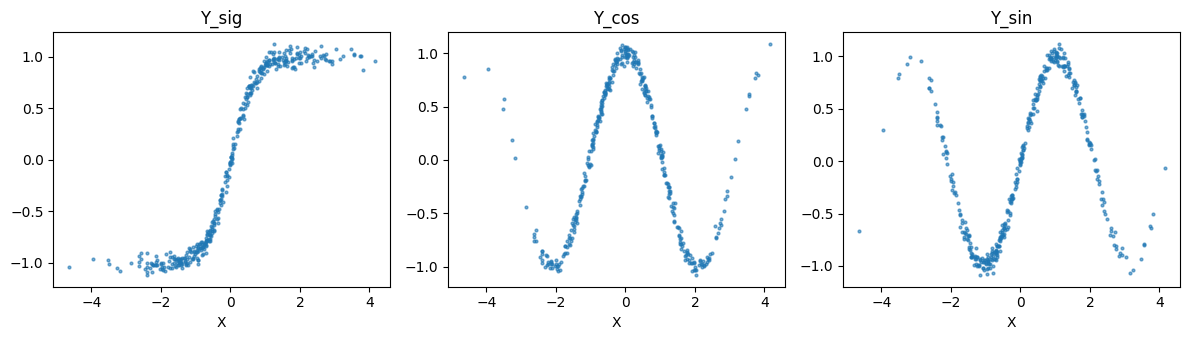

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
for ax, col in zip(axes, ["Y_sig", "Y_cos", "Y_sin"]):
    ax.scatter(df["X"], df[col], s=4, alpha=0.6)
    ax.set_title(col)
    ax.set_xlabel("X")
plt.tight_layout()

## 3. Post-nonlinear transform

`post_transform` warps the structural-function-plus-noise output element-wise.
Available transforms: `tanh`, `sin`, `cos`, `exp_neg_abs`, `sqrt_abs`, `relu`, `sign`.

In [7]:
pnl_cfg = {
    "simulation_params": {"n_samples": 300, "seed": 31},
    "graph_params": {
        "type": "custom",
        "nodes": ["X", "Y"],
        "edges": [["X", "Y"]],
    },
    "node_params": {
        "X": {"type": "continuous", "distribution": {"name": "gaussian", "mean": 0, "std": 2.0}},
        "Y": {
            "type": "continuous",
            "functional_form": {"name": "linear", "weights": {"X": 1.5}},
            "noise_model": {"name": "additive", "dist": "gaussian", "std": 0.4},
            "post_transform": {"name": "tanh"},
        },
    },
}
pnl = CausalDataGenerator(pnl_cfg).simulate()["data"]
pnl["Y"].describe()

count    300.000000
mean      -0.018034
std        0.855319
min       -1.000000
25%       -0.934246
50%       -0.216771
75%        0.959507
max        1.000000
Name: Y, dtype: float64

## 4. Heavy-tailed noise

`additive` noise accepts `laplace`, `cauchy`, and `uniform` in addition to
`gaussian`, `student_t`, `gamma`, and `exponential`.

In [8]:
heavy_cfg = {
    "simulation_params": {"n_samples": 300, "seed": 41},
    "graph_params": {
        "type": "custom",
        "nodes": ["X", "Y_lap", "Y_cau"],
        "edges": [["X", "Y_lap"], ["X", "Y_cau"]],
    },
    "node_params": {
        "X": {"type": "continuous", "distribution": {"name": "gaussian", "mean": 0, "std": 1.0}},
        "Y_lap": {
            "type": "continuous",
            "functional_form": {"name": "linear", "weights": {"X": 1.0}},
            "noise_model": {"name": "additive", "dist": "laplace", "scale": 0.7},
        },
        "Y_cau": {
            "type": "continuous",
            "functional_form": {"name": "linear", "weights": {"X": 1.0}},
            "noise_model": {"name": "additive", "dist": "cauchy", "scale": 0.3},
        },
    },
}
heavy = CausalDataGenerator(heavy_cfg).simulate()["data"]
heavy.describe().round(2)

,X,Y_cau,Y_lap
count,300.00,300.00,300.00
mean,-0.04,-0.79,0.00
std,0.93,21.08,1.35
min,-2.57,-350.05,-3.57
25%,-0.67,-0.73,-0.80
50%,-0.09,-0.09,0.01
75%,0.47,0.60,0.83
max,2.91,62.31,4.29


## 5. Mixed-type DAG (categorical → continuous via stratum_means)

Categorical parents select a stratum mean; metric parents add a linear
contribution via `metric_weights`.

In [9]:
mixed_cfg = {
    "simulation_params": {
        "n_samples": 400,
        "seed": 51,
        "categorical_parent_metric_form_policy": "stratum_means",
    },
    "graph_params": {
        "type": "custom",
        "nodes": ["C", "X", "Y"],
        "edges": [["C", "Y"], ["X", "Y"]],
    },
    "node_params": {
        "C": {"type": "categorical", "cardinality": 3},
        "X": {"type": "continuous", "distribution": {"name": "gaussian", "mean": 0, "std": 1}},
        "Y": {
            "type": "continuous",
            "functional_form": {
                "name": "stratum_means",
                "strata_means": {"C=0": -1.0, "C=1": 0.0, "C=2": 1.5},
                "metric_weights": {"X": 0.8},
            },
            "noise_model": {"name": "additive", "dist": "gaussian", "std": 0.2},
        },
    },
}
mixed = CausalDataGenerator(mixed_cfg).simulate()["data"]
mixed.groupby("C")["Y"].agg(["mean", "std", "count"]).round(2)

,mean,std,count
C,,,
0,-1.02,0.80,153
1,0.01,0.87,158
2,1.40,0.79,89


Per-stratum means in `Y` should track `strata_means` (offset by the linear
contribution from `X`, which has mean ~0).

## Where to next

- [Model Formulations](https://averinpa.github.io/dagsampler/formulations.html) — math for every supported mechanism
- [Configuration Examples](https://averinpa.github.io/dagsampler/config_examples.html) — JSON snippets for every option
- [Template Configurations](https://averinpa.github.io/dagsampler/templates.html) — full `chain_config` / `fork_config` / `collider_config` reference
- [API Reference](https://averinpa.github.io/dagsampler/api.html) — auto-generated from docstrings